# Visualisation d'un dataset BSS

Charge une scène depuis son manifeste, affiche ses métadonnées, ses signaux temporels et les spectrogrammes du mélange reçu par les microphones.

In [25]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt

# Recherche la racine du dépôt, que le notebook soit lancé depuis Beluga
# ou depuis BSS/Dataset.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'BSS').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'BSS').is_dir():
    raise FileNotFoundError('Impossible de trouver la racine du dépôt Beluga.')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from BSS.Dataset import load_scene

In [26]:
# Paramètres à adapter
dataset_root = repo_root / 'BSS' / 'Dataset' / 'generated' / 'whistles_only'
split = 'train'
scene_index = 2

In [27]:
manifest_path = dataset_root / split / 'manifest.jsonl'
with manifest_path.open(encoding='utf-8') as manifest:
    records = [json.loads(line) for line in manifest if line.strip()]

if not records:
    raise ValueError(f'Le manifeste {manifest_path} est vide.')
if not 0 <= scene_index < len(records):
    raise IndexError(f'scene_index doit être compris entre 0 et {len(records) - 1}.')

record = records[scene_index]
scene_path = manifest_path.parent / record['path']
scene = load_scene(scene_path)

print(f"Scène : {record['id']}")
print(f"Fichier : {scene_path}")
print(f"Seed : {record['seed']}")
print(f"Sources : {scene.sources.data.shape}")
print(f"Mélange : {scene.mixed.data.shape}")
print(f"Fréquence d'échantillonnage : {scene.metadata.fs} Hz")
scene.metadata

Scène : train_000002
Fichier : C:\Users\BORDERIES\Desktop\Cours\Stage canada\Beluga\BSS\Dataset\generated\whistles_only\train\scene_000002.npz
Seed : 44
Sources : (2, 24000)
Mélange : (3, 24000)
Fréquence d'échantillonnage : 8000 Hz


AudioSceneMetadata(fs=8000, duration=3.0, n_sources=2, n_mics=3, source_composites=[CompositeSignalMetadata(placements=[SignalPlacementMetadata(signal_type='whistle', signal_params={'time_duration': 1.1616957394582244, 'f_start': 1200.0, 'f_min': 600.0, 'f_max': 1200.0, 'segment_duration_range': [0.35, 0.9], 'direction_change_probability': 0.2, 'sweep_rate_range': [300.0, 1000.0], 'jitter_tau': 0.05, 'jitter_std': 4.0, 'harmonic_amplitudes': [1.0, 0.12289082276736521, 0.030631161760363748], 'harmonic_phases': [2.123477552128429, 4.258258048505741, 3.8737984481444907], 'envelope_base': 0.75, 'envelope_depth': 0.15, 'seed': 1742772004}, start_time=0.7562574854294499, duration=1.16175, window='hann', gain=0.9698209059891972)], duration=3.0, energy=1442.8318422090642), CompositeSignalMetadata(placements=[SignalPlacementMetadata(signal_type='whistle', signal_params={'time_duration': 0.5229103008034905, 'f_start': 1200.0, 'f_min': 600.0, 'f_max': 1200.0, 'segment_duration_range': [0.35, 0.9]

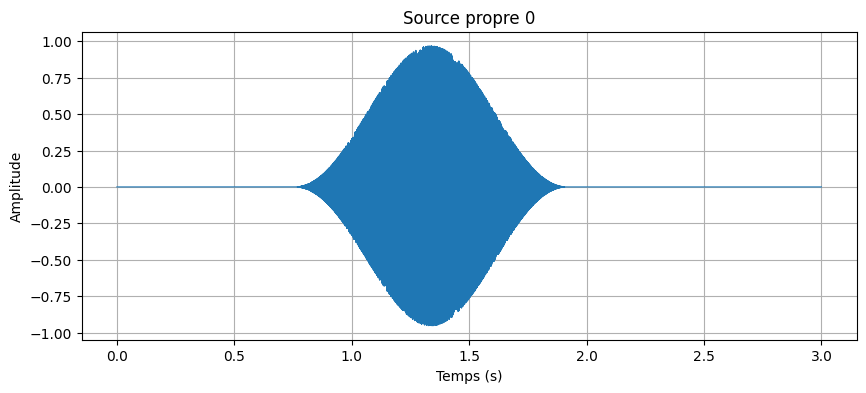

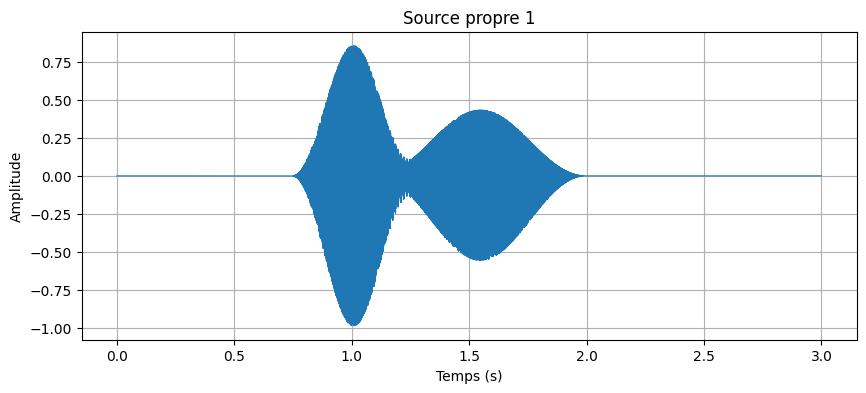

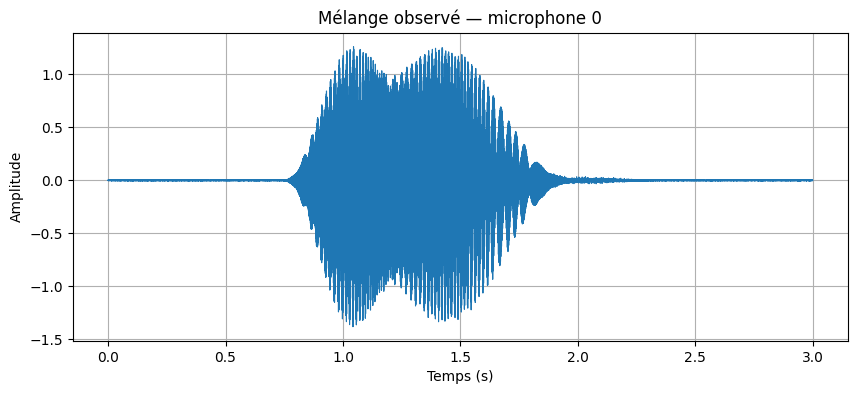

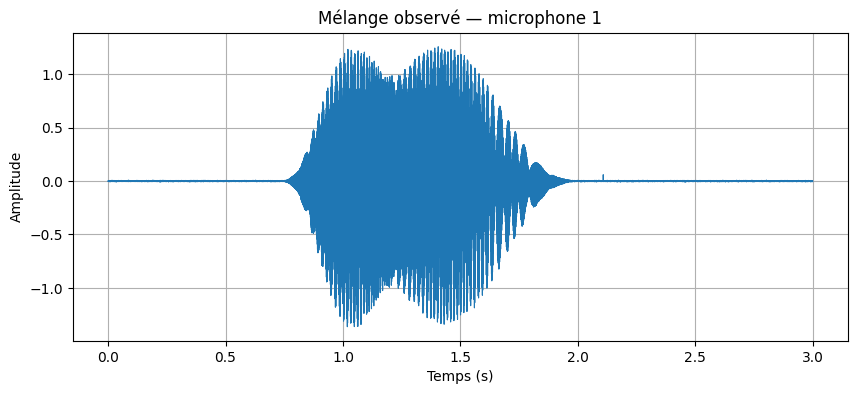

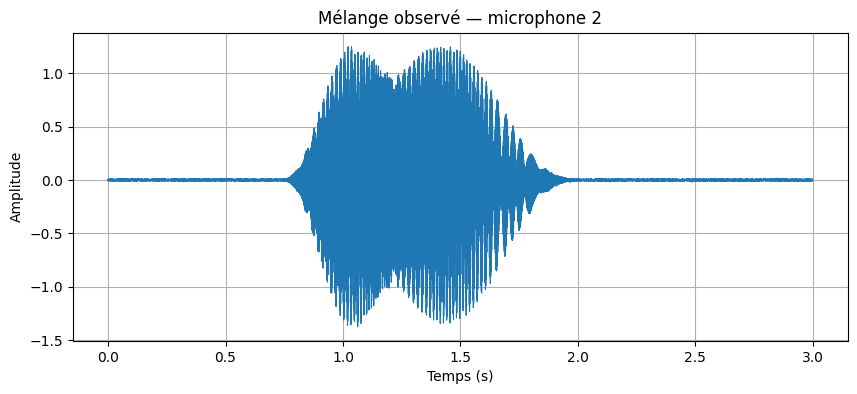

In [28]:
for source_index, signal in enumerate(scene.sources.signals):
    signal.plot(title=f'Source propre {source_index}', linewidth=0.8)

for mic_index, signal in enumerate(scene.mixed.signals):
    signal.plot(title=f'Mélange observé — microphone {mic_index}', linewidth=0.8)

plt.show()

Spectrogramme de la source propre 0
Spectrogramme de la source propre 1
Spectrogramme du microphone 0
Spectrogramme du microphone 1
Spectrogramme du microphone 2


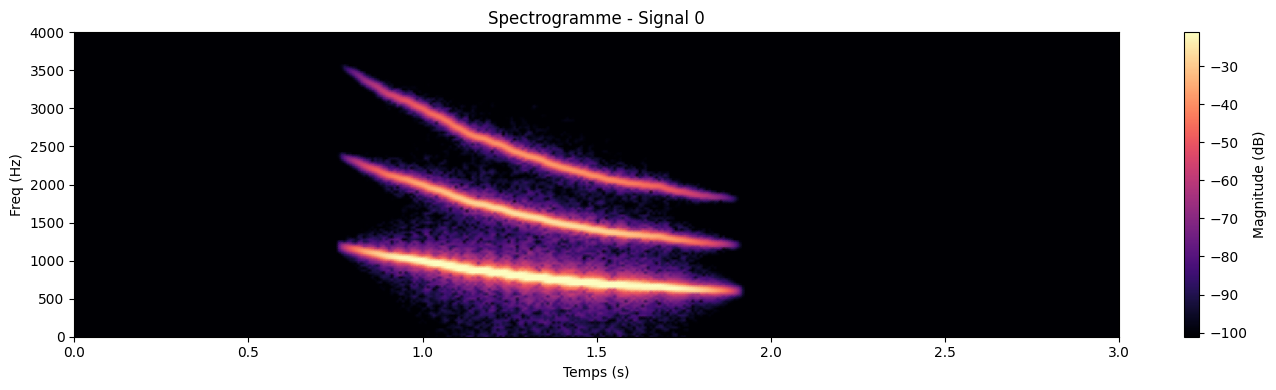

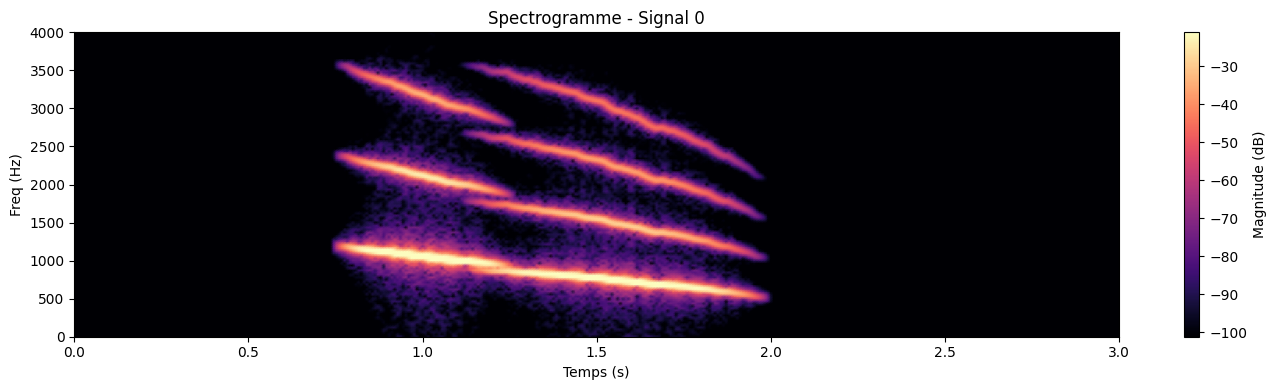

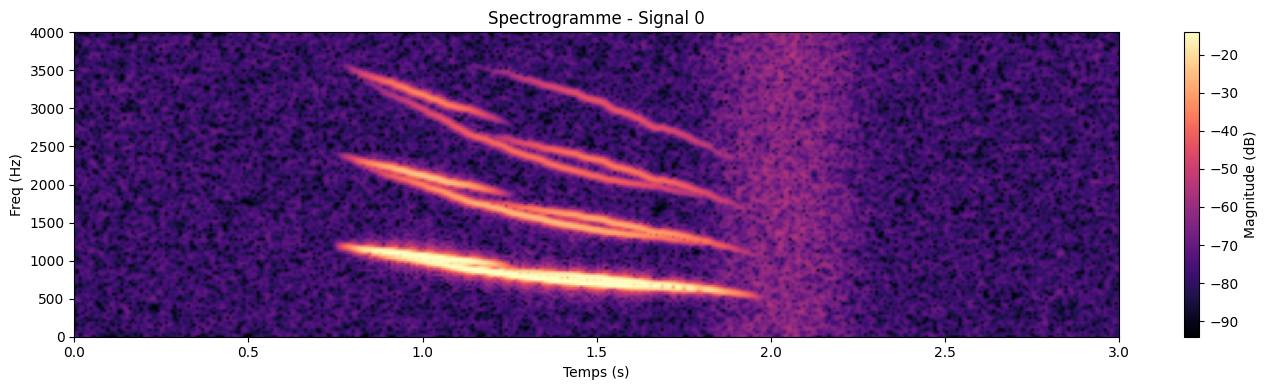

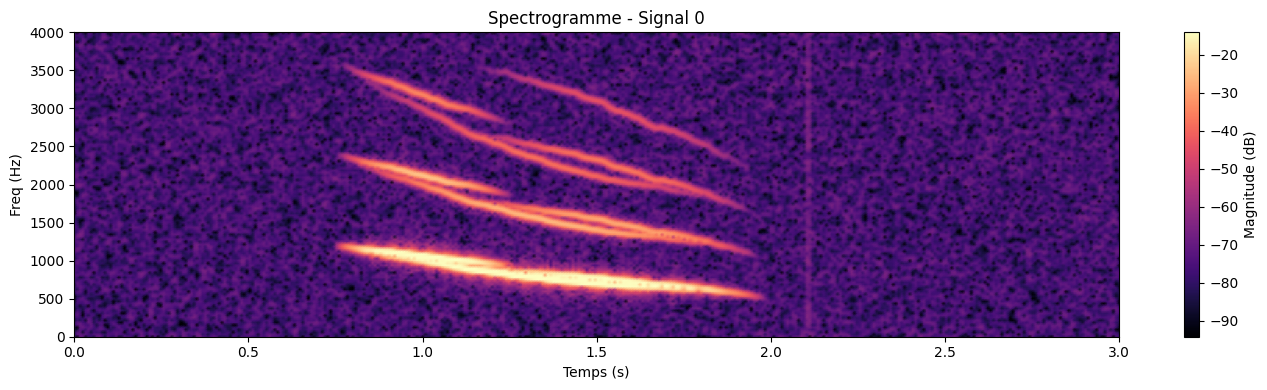

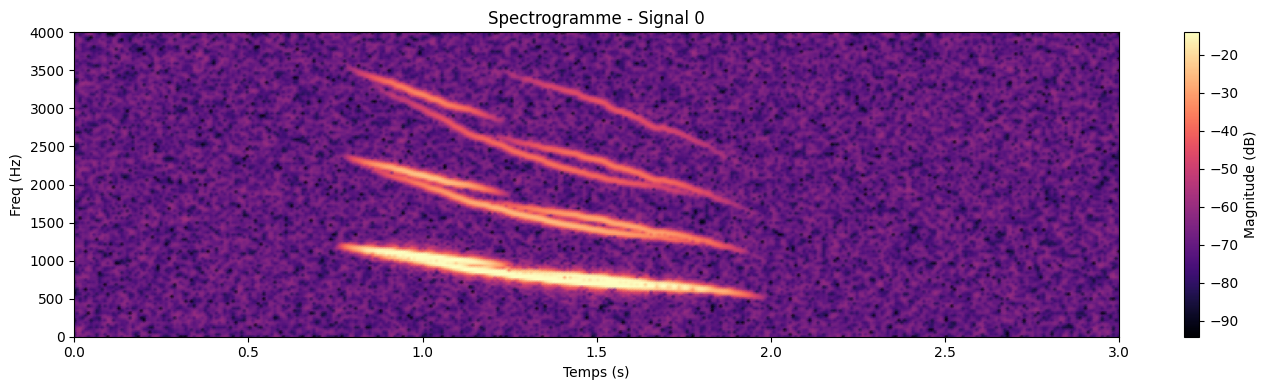

In [29]:
for source_index, signal in enumerate(scene.sources.signals):
    print(f'Spectrogramme de la source propre {source_index}')
    signal.plot_spectrogram(
        nperseg=256,
        noverlap=192,
        magnitude_scale='db',
        frequency_scale='linear',
        figsize=(14, 4),
    )

for mic_index, signal in enumerate(scene.mixed.signals):
    print(f'Spectrogramme du microphone {mic_index}')
    signal.plot_spectrogram(
        nperseg=256,
        noverlap=192,
        magnitude_scale='db',
        frequency_scale='linear',
        figsize=(14, 4),
    )

plt.show()